In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Import library yang diperlukan untuk pre-processing citra dan pengolahan citra

Baca gambar pakai plt. Plt baca gambar dengan format RGB. Setelah baca gambar, diubah ke grayscale dan ditampilkan menggunakan plt.imshow()

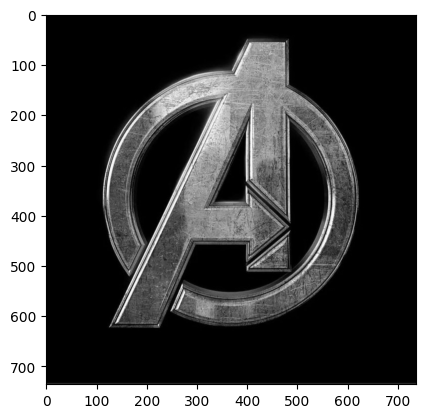

In [10]:
doomsday = plt.imread("doomsday.jpg")
doomsday_gray = cv2.cvtColor(doomsday, cv2.COLOR_BGR2GRAY)
plt.imshow(doomsday_gray, cmap='gray')

In [11]:
# Nilai filter Haar Wavelet
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HPF = np.array([1/np.sqrt(2), -(1/np.sqrt(2))])

# 1. Fungsi Konvolusi Horizontal manual
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, [0, ukuran_kernel], mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i][j+x] * kernel[x])
    return conv

# 2. Fungsi Konvolusi Vertikal manual 
def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, ukuran_kernel), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i+x][j] * kernel[x])
    return conv

# 3. Fungsi Downsampling Horizontal manual
def downsampling_h(image):
    baris = int(image.shape[0])
    kolom = int(image.shape[1] / 2)
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        indeks = 0
        for j in range(kolom):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

# 4. Fungsi Downsampling Vertikal manual
def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[i*2][j]
    return downsampled

# 5. Fungsi Normalisasi Intensitas manual
def normalisasi(image):
    # Pastikan perhitungan float selesai dulu, baru di-convert di baris return
    hasil = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return hasil.astype(np.uint8)

# 6. Fungsi Utama Dekomposisi Wavelet
def wavelet(image):
    # Cek apakah gambar RGB (3 channel) atau Grayscale (2 dimensi)
    if len(image.shape) == 3:
        num_channels = image.shape[2]
        # Siapkan array kosong untuk menampung hasil 3 channel
        app_rgb, hor_rgb, ver_rgb, diag_rgb = [], [], [], []
        
        # Lakukan perulangan untuk setiap channel (R, G, B)
        for c in range(num_channels):
            img_c = image[:, :, c]
            
            # --- Proses Wavelet per channel ---
            # LL
            konvolusil = convo_h(img_c, LPF)
            downsampling = downsampling_h(konvolusil)
            konvolusi2 = convo_v(downsampling, LPF)
            approximation = normalisasi(downsampling_v(konvolusi2))
            
            # LH
            konvolusil = convo_h(img_c, LPF)
            downsampling = downsampling_h(konvolusil)
            konvolusi2 = convo_v(downsampling, HPF)
            horizontal = normalisasi(downsampling_v(konvolusi2))
            
            # HL
            konvolusil = convo_h(img_c, HPF)
            downsampling = downsampling_h(konvolusil)
            konvolusi2 = convo_v(downsampling, LPF)
            vertikal = normalisasi(downsampling_v(konvolusi2))
            
            # HH
            konvolusil = convo_h(img_c, HPF)
            downsampling = downsampling_h(konvolusil)
            konvolusi2 = convo_v(downsampling, HPF)
            diagonal = normalisasi(downsampling_v(konvolusi2))
            
            app_rgb.append(approximation)
            hor_rgb.append(horizontal)
            ver_rgb.append(vertikal)
            diag_rgb.append(diagonal)
            
        # Gabungkan kembali (stack) menjadi format gambar RGB (Baris, Kolom, Channel)
        return (np.stack(app_rgb, axis=2), np.stack(hor_rgb, axis=2), 
                np.stack(ver_rgb, axis=2), np.stack(diag_rgb, axis=2))
    else:
        # Jika gambar grayscale bawaan, jalankan kode asli kamu
        # (Isi di bawah ini sama persis dengan kode aslimu)
        konvolusil = convo_h(image, LPF); downsampling = downsampling_h(konvolusil); konvolusi2 = convo_v(downsampling, LPF)
        approximation = normalisasi(downsampling_v(konvolusi2))
        konvolusil = convo_h(image, LPF); downsampling = downsampling_h(konvolusil); konvolusi2 = convo_v(downsampling, HPF)
        horizontal = normalisasi(downsampling_v(konvolusi2))
        konvolusil = convo_h(image, HPF); downsampling = downsampling_h(konvolusil); konvolusi2 = convo_v(downsampling, LPF)
        vertikal = normalisasi(downsampling_v(konvolusi2))
        konvolusil = convo_h(image, HPF); downsampling = downsampling_h(konvolusil); konvolusi2 = convo_v(downsampling, HPF)
        diagonal = normalisasi(downsampling_v(konvolusi2))
        return (approximation, horizontal, vertikal, diagonal)

# 7. Fungsi Upsampling Vertikal manual
def upsampling_v(image):
    baris, kolom = image.shape
    upsampled = np.zeros((baris * 2, kolom))
    for i in range(baris):
        for j in range(kolom):
            upsampled[i*2][j] = image[i][j]
    return upsampled

# 8. Fungsi Upsampling Horizontal manual
def upsampling_h(image):
    baris, kolom = image.shape
    upsampled = np.zeros((baris, kolom * 2))
    for i in range(baris):
        for j in range(kolom):
            upsampled[i][j*2] = image[i][j]
    return upsampled

# 9. Fungsi Rekonstruksi Wavelet manual
def rekonstruksi(LL, LH, HL, HH):
    if len(LL.shape) == 3:
        num_channels = LL.shape[2]
        hasil_rgb = []
        
        for c in range(num_channels):
            # Ambil sub-band per channel
            ll_c, lh_c, hl_c, hh_c = LL[:,:,c], LH[:,:,c], HL[:,:,c], HH[:,:,c]
            
            # --- Proses Rekonstruksi per channel ---
            upsampling = upsampling_v(ll_c); konvolusiL = convo_v(upsampling, LPF)
            upsampling = upsampling_v(lh_c); konvolusiH = convo_v(upsampling, HPF)
            upsampling = upsampling_h(konvolusiL + konvolusiH); konvolusiL2 = convo_h(upsampling, LPF)
            
            upsampling = upsampling_v(hl_c); konvolusiL = convo_v(upsampling, LPF)
            upsampling = upsampling_v(hh_c); konvolusiH = convo_v(upsampling, HPF)
            upsampling = upsampling_h(konvolusiL + konvolusiH); konvolusiH2 = convo_h(upsampling, HPF)
            
            hasil_c = konvolusiL2 + konvolusiH2
            hasil_rgb.append(hasil_c)
            
        return np.stack(hasil_rgb, axis=2)
    else:
        # Jika gambar grayscale bawaan, jalankan kode asli kamu
        upsampling = upsampling_v(LL); konvolusiL = convo_v(upsampling, LPF)
        upsampling = upsampling_v(LH); konvolusiH = convo_v(upsampling, HPF)
        upsampling = upsampling_h(konvolusiL + konvolusiH); konvolusiL2 = convo_h(upsampling, LPF)
        upsampling = upsampling_v(HL); konvolusiL = convo_v(upsampling, LPF)
        upsampling = upsampling_v(HH); konvolusiH = convo_v(upsampling, HPF)
        upsampling = upsampling_h(konvolusiL + konvolusiH); konvolusiH2 = convo_h(upsampling, HPF)
        return konvolusiL2 + konvolusiH2

Kode di atas merupakan implementasi manual dari sistem pemrosesan citra digital, yaitu **Dekomposisi Wavelet Haar** (*Discrete Wavelet Transform* / DWT). Seluruh proses matematis seperti konvolusi filter (menggunakan filter lolos rendah/LPF dan filter lolos tinggi/HPF), *downsampling*, serta *upsampling* untuk rekonstruksi gambar dibangun secara manual dari dasar menggunakan pustaka NumPy, baik untuk gambar berskala keabuan (*grayscale*) maupun gambar berwarna (RGB) yang diproses per saluran warna.

Proses utama dalam kode ini dibagi menjadi tiga tahapan besar yang saling berkaitan. Pertama, fungsi `wavelet` melakukan dekomposisi gambar menjadi empat sub-band detail, yaitu *Approximation* (LL/halus), *Horizontal* (LH), *Vertical* (HL), dan *Diagonal* (HH). Kedua, fungsi `rekonstruksi` bertugas mengembalikan sub-band tersebut menjadi gambar utuh semula melalui proses pembalikan.

Kode di bawah ini berfungsi untuk menerapkan fungsi dekomposisi wavelet Haar manual yang telah dibuat sebelumnya pada gambar `doomsday_gray`, lalu ditampilkan. Selanjutnya, ditampilkan keempat sub-band citra hasil dekomposisi secara bersamaan, yaitu **LL** (*Approximation*) di kiri atas, **LH** (*Horizontal Detail*) di kanan atas, **HL** (*Vertical Detail*) di kiri bawah, dan **HH** (*Diagonal Detail*) di kanan bawah.

Tujuan utama dilakukannya dekomposisi wavelet ini adalah untuk memisahkan informasi frekuensi rendah (struktur utama gambar) dengan informasi frekuensi tinggi (detail tepi dan tekstur) dari sebuah citra.

* Sub-band **LL** menyimpan versi gambar yang lebih kecil dan halus karena mereduksi *noise*, sehingga sangat berguna untuk kompresi data atau analisis bentuk makro.
* Sementara itu, sub-band **LH**, **HL**, dan **HH** mengisolasi perubahan intensitas piksel yang tajam pada arah tertentu, yang sangat efektif dimanfaatkan dalam proses ekstraksi fitur tekstur, deteksi tepi, serta analisis pola spasial pada tahapan pemrosesan citra selanjutnya.

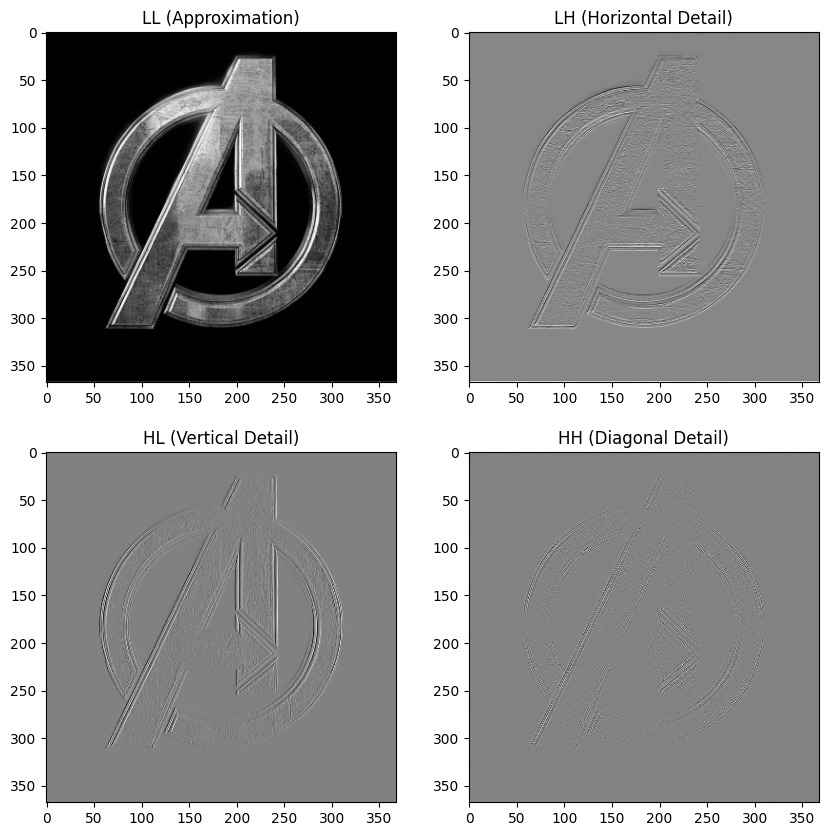

In [12]:
LL1, LH1, HL1, HH1 = wavelet(doomsday_gray)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(LL1, cmap='gray')
axes[0, 0].set_title("LL (Approximation)")

axes[0, 1].imshow(LH1, cmap='gray')
axes[0, 1].set_title("LH (Horizontal Detail)")

axes[1, 0].imshow(HL1, cmap='gray')
axes[1, 0].set_title("HL (Vertical Detail)")

axes[1, 1].imshow(HH1, cmap='gray')
axes[1, 1].set_title("HH (Diagonal Detail)")

plt.show()

Fungsi thresholding() digunakan untuk mengubah citra menjadi citra biner (hanya hitam dan putih). Fungsi ini memeriksa setiap piksel satu per satu, jika nilai piksel tersebut sama dengan atau lebih besar dari batas parameter angka yang ditentukan, maka piksel akan diubah menjadi putih (255), dan jika di bawahnya akan diubah menjadi hitam (0).

Semua sub-band, kecuali LL dilakukan operasi thresholding dengan nilai threshold 150. Hasilnya ditampilkan pada gambar di bawah ini.

Analisis perbedaan ketiga gambar:

* **HL Threshold (Horizontal Detail):** Menyoroti tepi-tepi vertikal dari objek. Hal ini terlihat jelas dari garis-garis pembentuk huruf "A" bagian tegak/vertikal dan sisi kanan-kiri lingkaran yang tampak menonjol dan bersih.
* **LH Threshold (Vertical Detail):** Menyoroti tepi-tepi horizontal dari objek. Fokus intensitas putih beralih pada bagian atas-bawah lingkaran luar serta lengkungan mendatar pada logo.
* **HH Threshold (Diagonal Detail):** Menyoroti komponen sudut atau tepi diagonal dari objek. Karena intensitas energinya paling kecil dan hanya mengambil detail serong, gambarnya terlihat paling tipis, redup, dan hanya menyisakan guratan pada bagian logo yang memiliki kemiringan tajam.

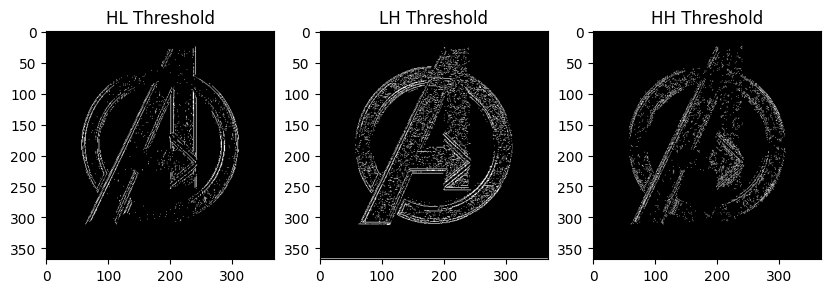

In [13]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)

    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

# Ambil hanya output citranya saja dengan menambahkan [1] atau menambah variabel '_'
HL_thres = thresholding(HL1, 150)
LH_thres = thresholding(LH1, 150)
HH_thres = thresholding(HH1, 150)

# Setup subplot
plt.figure(figsize=(10, 4)) # Opsional: memperluas ukuran canvas agar tidak penyok

plt.subplot(131)
plt.imshow(HL_thres, cmap='gray') # Tambahkan cmap='gray'
plt.title("HL Threshold")

plt.subplot(132)
plt.imshow(LH_thres, cmap='gray') # Tambahkan cmap='gray'
plt.title("LH Threshold")

plt.subplot(133)
plt.imshow(HH_thres, cmap='gray') # Tambahkan cmap='gray'
plt.title("HH Threshold")

plt.show()

In [14]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]])

def pad_image(img, pad_size):
    return np.pad(img, pad_size, mode='edge')

def erosi_grayscale(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    img_padded = pad_image(img, ((pad_h, pad_h), (pad_w, pad_w)))
    result = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            # Ambil region of interest (ROI) sewarna kernel
            roi = img_padded[i:i+kh, j:j+kw]
            result[i, j] = np.min(roi)
            
    return result

def dilasi_grayscale(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    img_padded = pad_image(img, ((pad_h, pad_h), (pad_w, pad_w)))
    result = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            roi = img_padded[i:i+kh, j:j+kw]
            result[i, j] = np.max(roi)
            
    return result

def opening_grayscale(img, kernel):
    return dilasi_grayscale(erosi_grayscale(img, kernel), kernel)

def closing_grayscale(img, kernel):
    return erosi_grayscale(dilasi_grayscale(img, kernel), kernel)

Kode di atas mengimplementasikan berbagai operasi morfologi citra pada skala abu-abu (grayscale morphology) menggunakan pendekatan sliding window manual dengan dukungan fungsi padding tepi (pad_image) agar ukuran citra output tetap konsisten. Dua operasi dasar yang menjadi fondasi utama adalah erosi_grayscale, yang memperkecil objek cerah dengan mengambil nilai minimum (np.min) pada area cakupan kernel, dan dilasi_grayscale, yang memperbesar objek cerah dengan mengambil nilai maksimum (np.max) pada area tersebut.

Dari dua operasi dasar tersebut, dikembangkan fungsi opening_grayscale (erosi diikuti dilasi) untuk menghapus gangguan atau objek kecil yang cerah, serta closing_grayscale (dilasi diikuti erosi) yang berfungsi menutup lubang kecil atau menyambung retakan pada objek.

Sub-band HL, LH, dan HH dilakukan operasi closing dengan `kernel5` yang sudah diinisialisasi sebelumnya. Hasilnya ditampilkan pada ketiga gambar di bawah ini.

Analisis perbedaan ketiga gambar:

* **Gambar Pertama (HL Closing):** Garis-garis tepi vertikal pada logo Avengers dan lingkaran luar menjadi jauh lebih tebal, solid, dan menyatu. Celah-celah kosong kecil di sepanjang guratan vertikal berhasil ditutup, menyisakan area hitam hanya pada bagian tengah logo yang tidak memiliki struktur vertikal dominan.
* **Gambar Kedua (LH Closing):** Area putih tampak paling dominan dan tebal di antara ketiganya karena struktur horizontal pada bagian atas dan bawah lingkaran luar serta potongan melintang logo menyatu dengan kuat. Efek pelebaran dari struktur horizontal ini membuat detail lubang hitam di dalam logo menyempit secara signifikan.
* **Gambar Ketiga (HH Closing):** Pola diagonal yang sebelumnya sangat tipis, samar, dan terputus-putus kini bertransformasi menjadi gumpalan putih yang lebih padat dan tegas. Meskipun detail sudut dan kemiringan serongnya berhasil diperjelas, citra ini tetap mempertahankan karakteristik uniknya yang menyisakan ruang kosong (hitam) pada area yang murni vertikal atau horizontal.

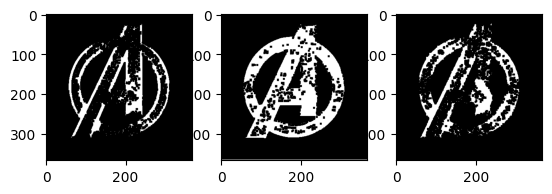

In [15]:
HL_closing = closing_grayscale(HL_thres, kernel5)
LH_closing = closing_grayscale(LH_thres, kernel5)
HH_closing = closing_grayscale(HH_thres, kernel5)

plt.subplot(131)
plt.imshow(HL_closing, cmap='gray')
plt.subplot(132)
plt.imshow(LH_closing, cmap='gray')
plt.subplot(133)
plt.imshow(HH_closing, cmap='gray')

Ketiga gambar di bawah ini hasil dari rekonstruksi menggunakan kombinasi sub-band frekuensi yang berbeda pada logo Avengers. Perbedaan mendasar di antara ketiganya terletak pada keberadaan komponen aproksimasi (LL) dan kondisi sub-band detail (LH, HL, HH) yang digunakan:

* **Hasil Rekonstruksi Asli:** Menampilkan citra logo yang utuh, jelas, dan natural. Hal ini terjadi karena rekonstruksi menggunakan sub-band aproksimasi ($LL1$) asli yang menyimpan mayoritas informasi frekuensi rendah (konten visual utama dan kecerahan dasar), berpadu sempurna dengan seluruh sub-band detail frekuensi tinggi asli.
* **Hasil Rekonstruksi LL = 0:** Gambar kehilangan komponen latar belakang abu-abu dan kecerahan utamanya, sehingga objek tampak transparan dan menyisakan garis tepi yang sangat tipis (*high-pass filter effect*). Fenomena ini terjadi karena sub-band aproksimasi dikosongkan ($LL = 0$), memaksa proses rekonstruksi hanya mengandalkan sub-band detail ($LH1, HL1, HH1$) asli yang murni berisi informasi perubahan intensitas tepi/sudut yang tajam.
* **Hasil Rekonstruksi LH, HL, HH Closing:** Objek tepi yang dihasilkan terlihat jauh lebih kasar, tebal, dan terfragmentasi membentuk tekstur seperti pahatan atau gumpalan kotak-kotak dibanding gambar kedua. Efek visual ini muncul karena rekonstruksi tidak hanya membuang komponen aproksimasi ($LL = 0$), tetapi juga menggunakan sub-band detail yang telah dimodifikasi lewat operasi morfologi *Closing* ($LH\_closing, HL\_closing, HH\_closing$) yang sebelumnya telah mempertebal dan menyatukan piksel-piksel detail secara paksa.

<Axes: >

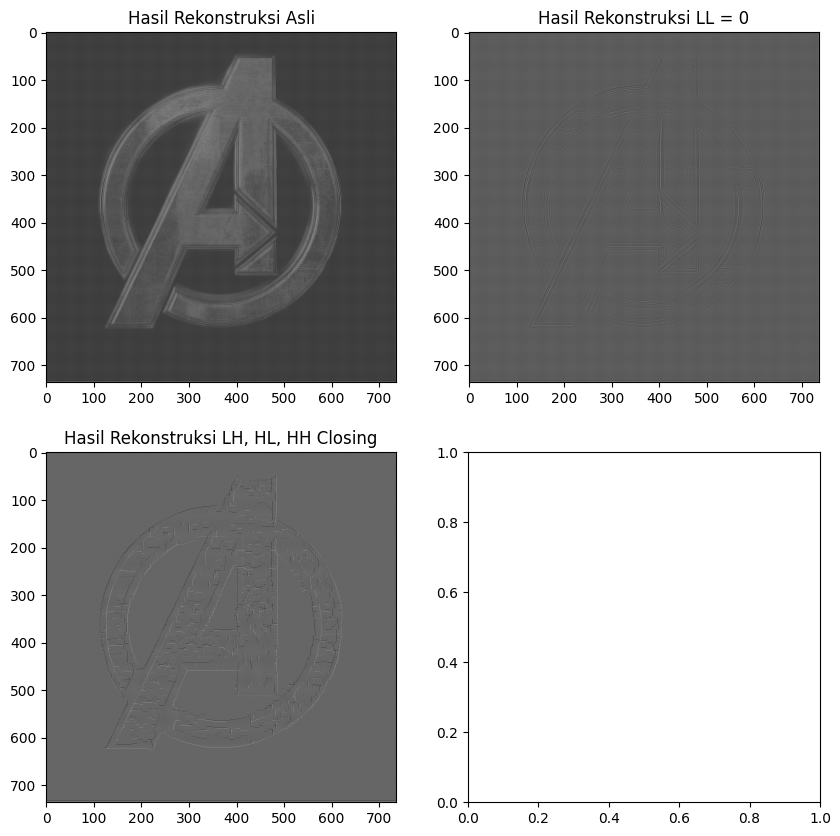

In [ ]:
rekonstruksi_asli = rekonstruksi(LL1, LH1, HL1, HH1)
LL_zero = np.zeros_like(LL1)
rekonstruksi_LL0 = rekonstruksi(LL_zero, LH1, HL1, HH1)
rekonstruksi_LL0_closing = rekonstruksi(LL_zero, LH_closing, HL_closing, HH_closing)

plt.figure(figsize=(10,10))

plt.subplot(221)
plt.title("Hasil Rekonstruksi Asli")
plt.imshow(rekonstruksi_asli, cmap='gray')
plt.subplot(222)
plt.title("Hasil Rekonstruksi LL = 0")
plt.imshow(rekonstruksi_LL0, cmap='gray')
plt.subplot(223)
plt.title("Hasil Rekonstruksi LH, HL, HH Closing")
plt.imshow(rekonstruksi_LL0_closing, cmap='gray')
# plt.subplot(224)
